# 📊 Praktikum Data Science - Pertemuan 4

## Statistika Dasar dan Analisis Data

👩‍🎓 Nama : Deviani Solikhah  
🆔 NIM : 240401010137  
🏫 Kelas : IF403  
💻 Program Studi : S1 PJJ Informatika  

---

### 🎯 Tujuan Praktikum

Pada praktikum ini saya mempelajari konsep statistika dasar dan analisis data menggunakan Dataset Iris. Kegiatan yang dilakukan meliputi perhitungan statistika deskriptif seperti mean, median, varians, standar deviasi, skewness, dan kurtosis. Selain itu dilakukan analisis distribusi data menggunakan histogram dan KDE, analisis univariat menggunakan boxplot dan violin plot, serta analisis bivariat menggunakan korelasi Pearson, scatter plot, dan heatmap untuk memahami hubungan antar variabel dalam dataset.

---

In [2]:
# Import Library dan Load Dataset 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = sns.load_dataset('iris') 

In [11]:
# Load & Inspect Dataset

print("📊 Shape Dataset")
print(df.shape)

print("\n📋 Tipe Data")
print(df.dtypes)

print("\n🔍 5 Data Pertama")
print(df.head())

print("\n📈 Statistik Deskriptif")
print(df.describe().round(3)) 

📊 Shape Dataset
(150, 5)

📋 Tipe Data
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

🔍 5 Data Pertama
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

📈 Statistik Deskriptif
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4

In [12]:
# Statistik Deskriptif

print("📊 Statistik Deskriptif Lengkap")

for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]

    print(f"\n{'='*40}")
    print(f"📌 {col_name.upper()}")
    print(f"{'='*40}")

    print(f"📊 Mean      : {col.mean():.3f}")
    print(f"📍 Median    : {col.median():.3f}")
    print(f"📏 Std Dev   : {col.std():.3f}")
    print(f"📐 Varians   : {col.var():.3f}")
    print(f"↔️ Skewness  : {col.skew():.3f}")
    print(f"📈 Kurtosis  : {col.kurt():.3f}") 

📊 Statistik Deskriptif Lengkap

📌 SEPAL_LENGTH
📊 Mean      : 5.843
📍 Median    : 5.800
📏 Std Dev   : 0.828
📐 Varians   : 0.686
↔️ Skewness  : 0.315
📈 Kurtosis  : -0.552

📌 SEPAL_WIDTH
📊 Mean      : 3.057
📍 Median    : 3.000
📏 Std Dev   : 0.436
📐 Varians   : 0.190
↔️ Skewness  : 0.319
📈 Kurtosis  : 0.228

📌 PETAL_LENGTH
📊 Mean      : 3.758
📍 Median    : 4.350
📏 Std Dev   : 1.765
📐 Varians   : 3.116
↔️ Skewness  : -0.275
📈 Kurtosis  : -1.402

📌 PETAL_WIDTH
📊 Mean      : 1.199
📍 Median    : 1.300
📏 Std Dev   : 0.762
📐 Varians   : 0.581
↔️ Skewness  : -0.103
📈 Kurtosis  : -1.341


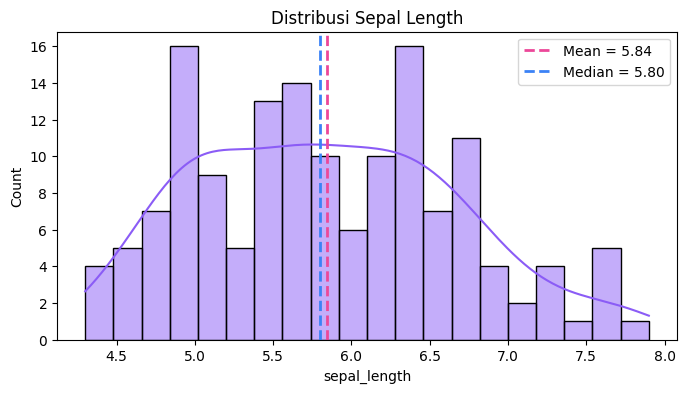

In [22]:
# Analisis Distribusi (Histogram + KDE) 

fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    df['sepal_length'],
    kde=True,
    bins=20,
    color="#8B5CF6",
    ax=ax
)

ax.axvline(
    df['sepal_length'].mean(),
    color='#EC4899',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

ax.axvline(
    df['sepal_length'].median(),
    color='#3B82F6',
    linestyle='--',
    linewidth=2,
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title("Distribusi Sepal Length")
ax.legend()

plt.show() 

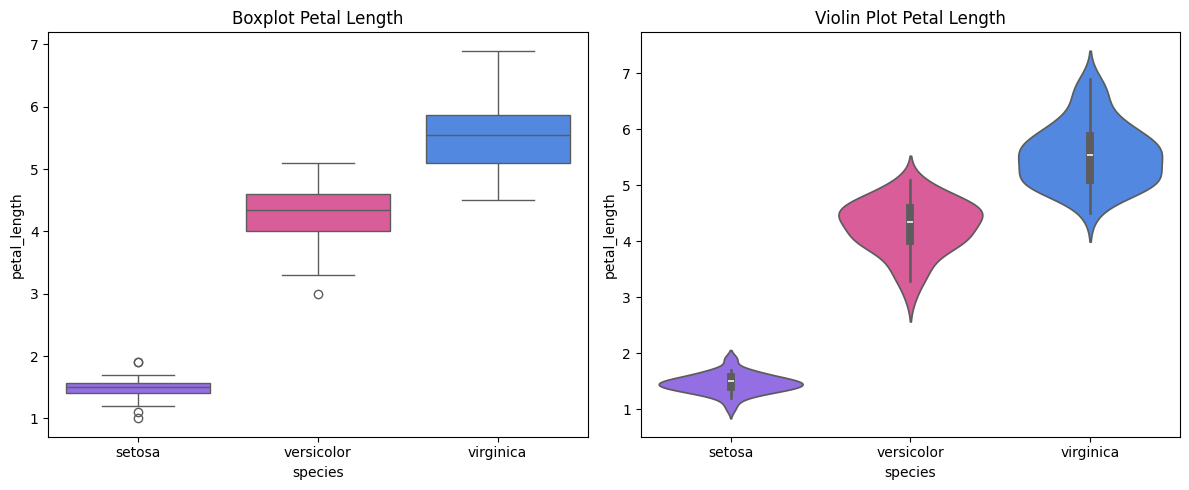

In [23]:
# Boxplot dan Violin Plot 

fig, axes = plt.subplots(1,2, figsize=(12,5))

custom_palette = [
    "#8B5CF6",
    "#EC4899",
    "#3B82F6"
]

sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette=custom_palette,
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Boxplot Petal Length")

sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette=custom_palette,
    legend=False,
    inner='box',
    ax=axes[1]
)

axes[1].set_title("Violin Plot Petal Length")

plt.tight_layout()
plt.show() 

In [16]:
# Matriks Korelasi Pearson 

corr = df.drop('species', axis=1).corr(method='pearson')

print("📊 Matriks Korelasi Pearson")
print(corr.round(3))

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()

print("\n🏆 Korelasi Tertinggi")
print(f"{max_pair} = {corr.loc[max_pair]:.3f}") 

📊 Matriks Korelasi Pearson
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

🏆 Korelasi Tertinggi
('petal_width', 'petal_length') = 0.963


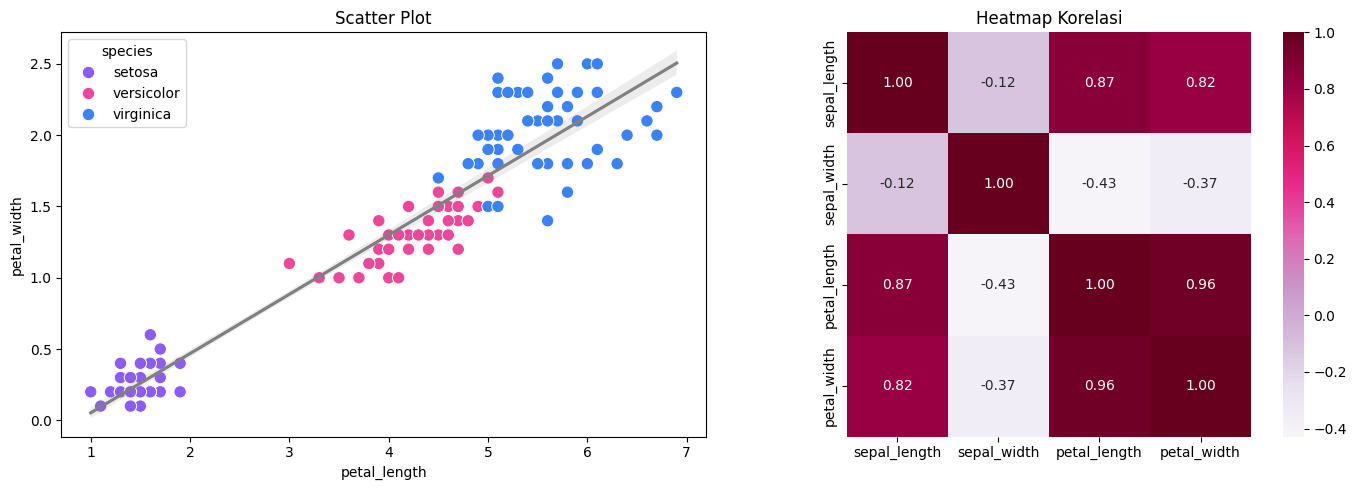

In [24]:
# Scatter Plot dan Heatmap 

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette=["#8B5CF6","#EC4899","#3B82F6"],
    s=80,
    ax=axes[0]
)

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title("Scatter Plot")

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='PuRd',
    square=True,
    ax=axes[1]
)

axes[1].set_title("Heatmap Korelasi")

plt.tight_layout()
plt.show() 

## 📝 Kesimpulan

Pada praktikum ini saya mempelajari konsep statistika dasar dan analisis data menggunakan Python dan Dataset Iris. Tahapan yang dilakukan meliputi perhitungan statistika deskriptif, analisis distribusi data, analisis univariat, serta analisis bivariat menggunakan korelasi Pearson.

Dari praktikum ini saya memahami bahwa statistika deskriptif dan visualisasi data merupakan langkah awal yang sangat penting dalam proses Data Science sebelum dilakukan analisis lanjutan maupun pembuatan model machine learning.